# 03 Exploratory Data Analysis

## Objective

Explore the cleaned housing and macroeconomic dataset to identify patterns in housing affordability stress across countries and over time.

## Input

- `data/processed/housing_macro_with_stress_score.csv`

## Key Questions

1. Which countries have the highest housing affordability stress in the latest year?
2. Which countries have the lowest housing affordability stress in the latest year?
3. How has housing affordability stress changed over time?
4. Which countries experienced the largest deterioration in affordability stress?
5. How are price-to-income, price-to-rent, urban population growth, and income growth related to housing stress?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")

Setup complete


In [2]:
df = pd.read_csv(PROCESSED_DIR / "housing_macro_with_stress_score.csv")

print("Shape:", df.shape)
df.head()

Shape: (902, 27)


,country_id,country_name,year,nominal_house_price_index,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,rent_price_index,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,...,rent_price_yoy_growth_pct,gdp_per_capita_yoy_growth_pct,house_price_income_gap,price_to_income_ratio_scaled,real_house_price_index_scaled,price_to_rent_ratio_scaled,urban_population_growth_pct_scaled,house_price_income_gap_scaled,housing_affordability_stress_score,housing_stress_category
0,AUS,Australia,2000,33.595673,67.822665,58.062251,47.961090,57.862362,45979.076565,21908.996802,...,NaN,NaN,0.629113,0.076037,0.260003,0.104041,0.456003,0.728783,23.090065,Low
1,AUS,Australia,2001,37.368512,69.777135,62.618848,51.543695,59.662722,46314.623530,19733.651010,...,3.111453,0.729782,6.740034,0.088434,0.279783,0.135394,0.483803,0.772478,25.360450,Low
2,AUS,Australia,2002,44.372389,81.271639,72.558473,59.617939,61.144035,47599.407929,20335.096019,...,2.482811,2.774036,12.890817,0.161339,0.324362,0.203785,0.479150,0.816459,30.787703,Low
3,AUS,Australia,2003,52.375657,91.792473,84.071694,68.972989,62.283510,48509.663218,23757.589847,...,1.863592,1.912325,13.779345,0.228068,0.376013,0.283004,0.479148,0.822812,36.062383,Low
4,AUS,Australia,2004,55.647000,91.233649,87.154344,72.246883,63.855978,50018.590448,30886.050095,...,2.524693,3.110570,1.636061,0.224524,0.394088,0.304215,0.465724,0.735983,35.811907,Low


In [3]:
print("Countries:", df["country_id"].nunique())
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())

df[[
    "country_id",
    "country_name",
    "year",
    "housing_affordability_stress_score",
    "housing_stress_category"
]].head()

Countries: 40
Minimum year: 2000
Maximum year: 2024


,country_id,country_name,year,housing_affordability_stress_score,housing_stress_category
0,AUS,Australia,2000,23.090065,Low
1,AUS,Australia,2001,25.360450,Low
2,AUS,Australia,2002,30.787703,Low
3,AUS,Australia,2003,36.062383,Low
4,AUS,Australia,2004,35.811907,Low


## Latest Year Housing Stress Rankings

I ranked countries by their Housing Affordability Stress Score in the latest available year to identify the markets experiencing the strongest affordability pressure.

In [4]:
latest_year = df["year"].max()

latest_df = df[df["year"] == latest_year].copy()

latest_rankings = latest_df.sort_values(
    "housing_affordability_stress_score",
    ascending=False
)[[
    "country_id",
    "country_name",
    "year",
    "housing_affordability_stress_score",
    "housing_stress_category",
    "price_to_income_ratio",
    "real_house_price_index",
    "price_to_rent_ratio",
    "urban_population_growth_pct",
    "house_price_income_gap"
]]

latest_rankings.head(10)

,country_id,country_name,year,housing_affordability_stress_score,housing_stress_category,price_to_income_ratio,real_house_price_index,price_to_rent_ratio,urban_population_growth_pct,house_price_income_gap
754,PRT,Portugal,2024,75.350577,Severe,147.263891,179.975719,173.251483,1.296659,5.121149
442,HUN,Hungary,2024,65.532394,High,114.030745,181.990760,165.592641,-0.031061,6.655638
119,CAN,Canada,2024,65.080985,High,136.187074,144.157311,135.818676,3.174276,1.974281
659,NLD,Netherlands,2024,65.005220,High,130.538403,147.078229,161.189543,0.981329,4.977103
209,CZE,Czechia,2024,61.611459,High,121.209501,146.926102,158.898640,0.458402,0.954480
876,USA,United States,2024,61.418152,High,128.283383,154.038827,133.312750,1.042863,0.875864
404,GRC,Greece,2024,60.757467,High,116.000671,147.632588,160.327457,0.260311,4.771717
597,LTU,Lithuania,2024,58.640189,Moderate,113.093238,155.031808,134.816838,0.948111,6.144315
615,LUX,Luxembourg,2024,58.501367,Moderate,121.519397,131.338811,144.065509,1.619956,-6.579034
826,SVN,Slovenia,2024,57.455993,Moderate,120.953584,154.465260,117.430579,0.721876,3.963278


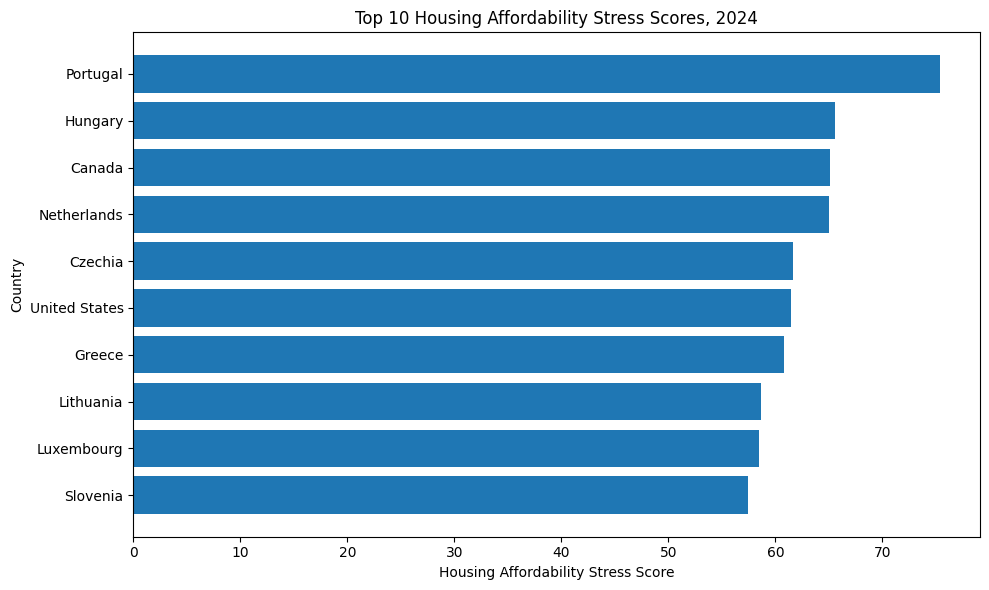

In [5]:
top_10_latest = latest_rankings.head(10).sort_values(
    "housing_affordability_stress_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_latest["country_name"],
    top_10_latest["housing_affordability_stress_score"]
)

plt.title(f"Top 10 Housing Affordability Stress Scores, {latest_year}")
plt.xlabel("Housing Affordability Stress Score")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(IMAGES_DIR / "top_10_housing_stress_latest_year.png", dpi=300)

plt.show()

### Initial Insight

In the latest available year, the highest housing affordability stress scores are concentrated in a small group of countries with elevated price-to-income pressure, real house price growth, or price-to-rent pressure.

This ranking provides a starting point for deeper analysis into whether stress is being driven primarily by house prices, income dynamics, rent pressure, or urban population growth.

## Lowest Housing Stress Countries

To provide contrast, I also reviewed the countries with the lowest Housing Affordability Stress Scores in the latest available year.

In [6]:
bottom_10_latest = latest_rankings.tail(10).sort_values(
    "housing_affordability_stress_score",
    ascending=True
)

bottom_10_latest[[
    "country_id",
    "country_name",
    "year",
    "housing_affordability_stress_score",
    "housing_stress_category",
    "price_to_income_ratio",
    "real_house_price_index",
    "price_to_rent_ratio"
]]

,country_id,country_name,year,housing_affordability_stress_score,housing_stress_category,price_to_income_ratio,real_house_price_index,price_to_rent_ratio
770,ROU,Romania,2024,32.356318,Low,55.834297,97.517294,107.834556
329,FIN,Finland,2024,34.560376,Low,81.077193,85.027428,86.497863
578,KOR,Korea,2024,35.705966,Low,77.511348,92.149016,102.276105
528,ITA,Italy,2024,38.231835,Low,87.042987,92.413621,102.976149
901,ZAF,South Africa,2024,39.570037,Low,89.264074,88.544944,101.261121
851,SWE,Sweden,2024,42.951205,Moderate,95.494507,102.028341,110.812999
354,FRA,France,2024,43.026947,Moderate,93.403485,103.880572,117.710993
74,BEL,Belgium,2024,44.382319,Moderate,96.745664,105.708081,111.753811
192,COL,Colombia,2024,44.979502,Moderate,88.075268,105.297679,123.238971
379,GBR,United Kingdom,2024,47.507928,Moderate,105.906467,108.957397,113.991544


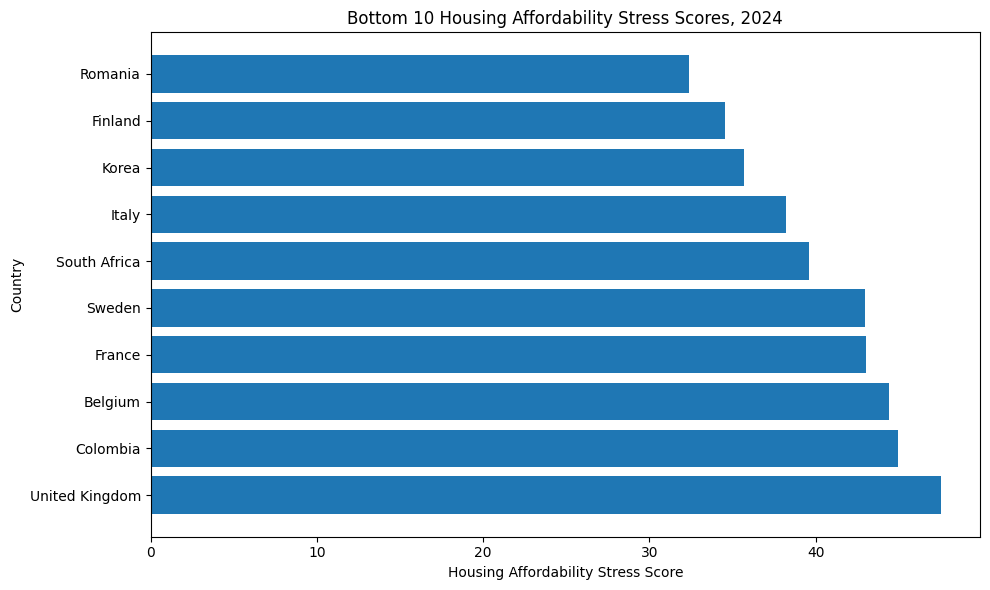

In [7]:
bottom_10_plot = bottom_10_latest.sort_values(
    "housing_affordability_stress_score",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    bottom_10_plot["country_name"],
    bottom_10_plot["housing_affordability_stress_score"]
)

plt.title(f"Bottom 10 Housing Affordability Stress Scores, {latest_year}")
plt.xlabel("Housing Affordability Stress Score")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(IMAGES_DIR / "bottom_10_housing_stress_latest_year.png", dpi=300)

plt.show()

### Initial Insight

The lowest-stress countries in the latest year generally show lower relative pressure across the composite indicators. Comparing the top and bottom groups helps identify whether high stress is mainly caused by elevated price-to-income ratios, stronger real house price growth, or valuation pressure from price-to-rent ratios.

## Housing Stress Trend Over Time

I analyzed the average Housing Affordability Stress Score by year to understand whether affordability pressure has increased or decreased over time across the countries in the dataset.

In [8]:
yearly_stress = (
    df
    .groupby("year", as_index=False)
    .agg(
        avg_housing_stress_score=("housing_affordability_stress_score", "mean"),
        median_housing_stress_score=("housing_affordability_stress_score", "median"),
        countries_count=("country_id", "nunique")
    )
)

yearly_stress.head()

,year,avg_housing_stress_score,median_housing_stress_score,countries_count
0,2000,35.460093,34.363203,25
1,2001,36.267005,33.817008,26
2,2002,37.842536,33.760053,28
3,2003,39.576645,36.844645,28
4,2004,41.639009,40.213333,28


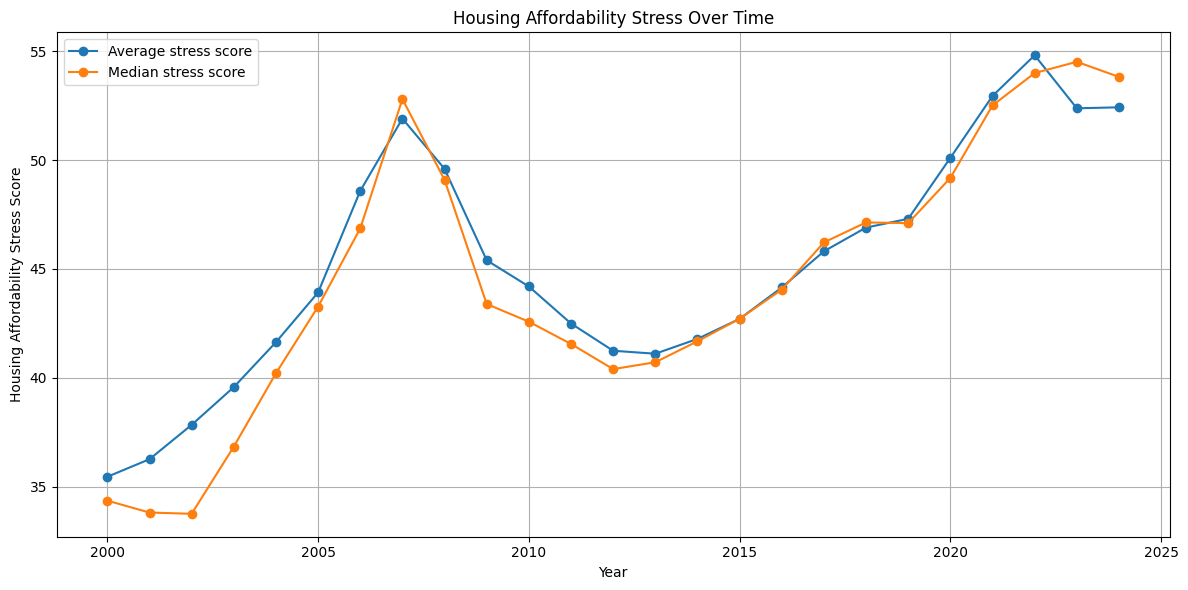

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_stress["year"],
    yearly_stress["avg_housing_stress_score"],
    marker="o",
    label="Average stress score"
)

plt.plot(
    yearly_stress["year"],
    yearly_stress["median_housing_stress_score"],
    marker="o",
    label="Median stress score"
)

plt.title("Housing Affordability Stress Over Time")
plt.xlabel("Year")
plt.ylabel("Housing Affordability Stress Score")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "housing_stress_trend_over_time.png", dpi=300)

plt.show()

### Initial Insight

Average and median housing affordability stress show how affordability pressure has evolved across the dataset over time. This trend view helps identify whether stress is broad-based or concentrated in specific years and countries.

A later dashboard view can combine this time trend with country-level filters to show whether stress is driven by a few high-pressure markets or by wider structural deterioration.

## Countries with the Largest Affordability Stress Deterioration

To identify countries where affordability pressure worsened the most, I compared each country's earliest available Housing Affordability Stress Score with its latest available score.

In [10]:
country_start_end = (
    df
    .sort_values(["country_id", "year"])
    .groupby("country_id")
    .agg(
        country_name=("country_name", "first"),
        first_year=("year", "first"),
        latest_year=("year", "last"),
        first_stress_score=("housing_affordability_stress_score", "first"),
        latest_stress_score=("housing_affordability_stress_score", "last")
    )
    .reset_index()
)

country_start_end["stress_score_change"] = (
    country_start_end["latest_stress_score"]
    - country_start_end["first_stress_score"]
)

country_start_end = country_start_end.sort_values(
    "stress_score_change",
    ascending=False
)

country_start_end.head(10)

,country_id,country_name,first_year,latest_year,first_stress_score,latest_stress_score,stress_score_change
4,CAN,Canada,2000,2024,21.544309,65.080985,43.536676
30,NZL,New Zealand,2000,2024,18.319336,54.507761,36.188425
0,AUS,Australia,2000,2024,23.090065,56.426518,33.336453
5,CHE,Switzerland,2000,2024,29.385477,56.095230,26.709753
11,ESP,Spain,2000,2024,33.079096,57.251904,24.172808
37,SWE,Sweden,2000,2024,19.029999,42.951205,23.921206
6,CHL,Chile,2002,2024,28.794998,51.378089,22.583091
29,NOR,Norway,2000,2024,26.387044,48.599748,22.212704
15,GBR,United Kingdom,2000,2024,25.868192,47.507928,21.639736
26,LUX,Luxembourg,2007,2024,37.352360,58.501367,21.149007


In [11]:
country_year_counts = (
    df
    .groupby("country_id")
    .agg(years_available=("year", "nunique"))
    .reset_index()
)

country_change = country_start_end.merge(
    country_year_counts,
    on="country_id",
    how="left"
)

country_change_filtered = country_change[
    country_change["years_available"] >= 10
].copy()

country_change_filtered.head(10)

,country_id,country_name,first_year,latest_year,first_stress_score,latest_stress_score,stress_score_change,years_available
0,CAN,Canada,2000,2024,21.544309,65.080985,43.536676,25
1,NZL,New Zealand,2000,2024,18.319336,54.507761,36.188425,25
2,AUS,Australia,2000,2024,23.090065,56.426518,33.336453,25
3,CHE,Switzerland,2000,2024,29.385477,56.095230,26.709753,25
4,ESP,Spain,2000,2024,33.079096,57.251904,24.172808,25
5,SWE,Sweden,2000,2024,19.029999,42.951205,23.921206,25
6,CHL,Chile,2002,2024,28.794998,51.378089,22.583091,23
7,NOR,Norway,2000,2024,26.387044,48.599748,22.212704,25
8,GBR,United Kingdom,2000,2024,25.868192,47.507928,21.639736,25
9,LUX,Luxembourg,2007,2024,37.352360,58.501367,21.149007,18


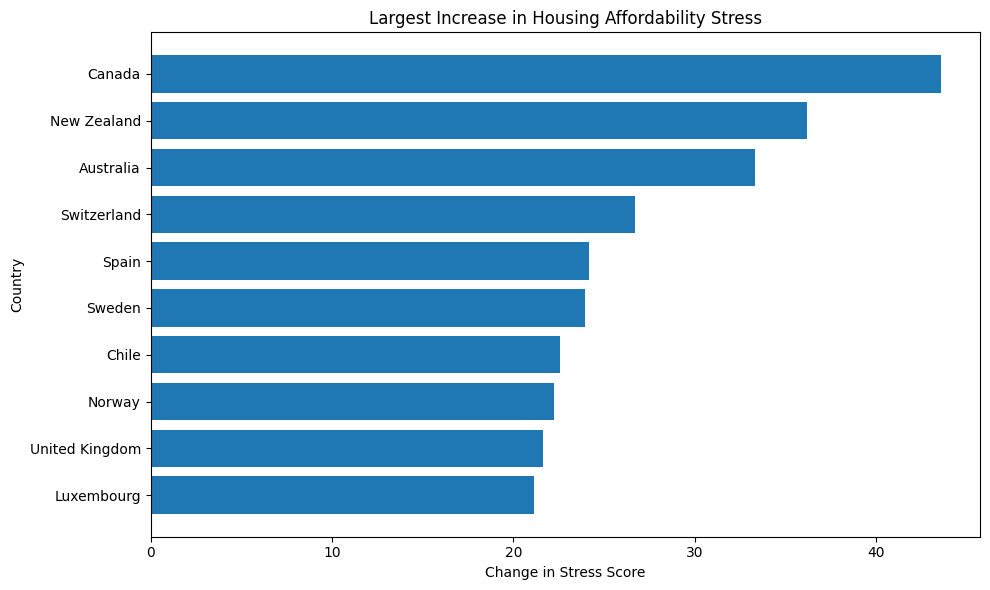

In [12]:
top_deterioration = country_change_filtered.head(10).sort_values(
    "stress_score_change",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_deterioration["country_name"],
    top_deterioration["stress_score_change"]
)

plt.title("Largest Increase in Housing Affordability Stress")
plt.xlabel("Change in Stress Score")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(IMAGES_DIR / "largest_housing_stress_deterioration.png", dpi=300)

plt.show()

### Initial Insight

Countries with the largest increase in stress score experienced the strongest deterioration in affordability conditions over the available period. This metric helps distinguish countries that are currently high-stress from countries where affordability has worsened most rapidly over time.

## Drivers of Housing Affordability Stress

To understand what is associated with higher housing stress, I compared the Housing Affordability Stress Score against key input indicators such as price-to-income, price-to-rent, urban population growth, and the house-price-income gap.

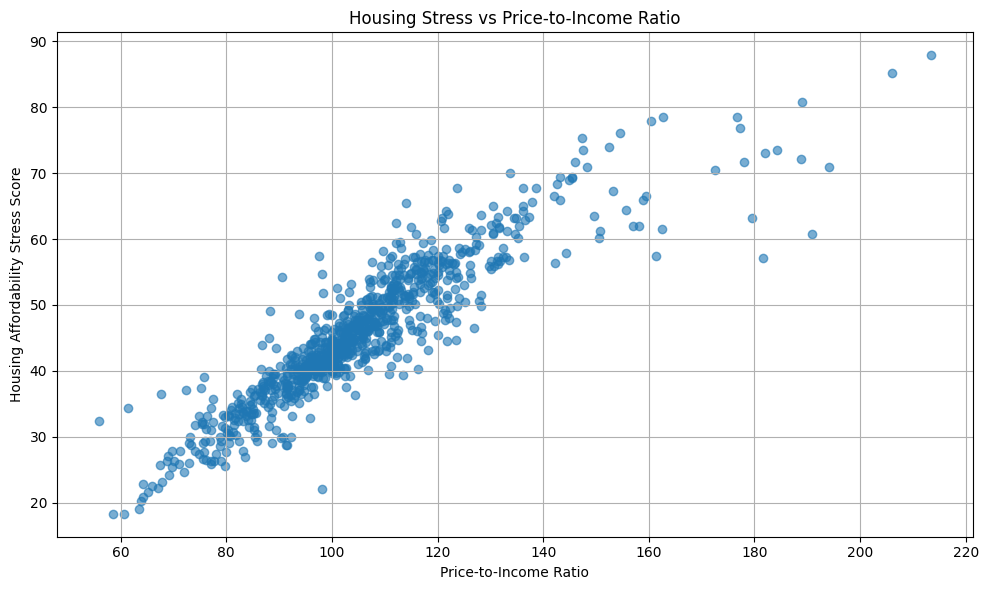

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["price_to_income_ratio"],
    df["housing_affordability_stress_score"],
    alpha=0.6
)

plt.title("Housing Stress vs Price-to-Income Ratio")
plt.xlabel("Price-to-Income Ratio")
plt.ylabel("Housing Affordability Stress Score")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "stress_vs_price_to_income.png", dpi=300)

plt.show()

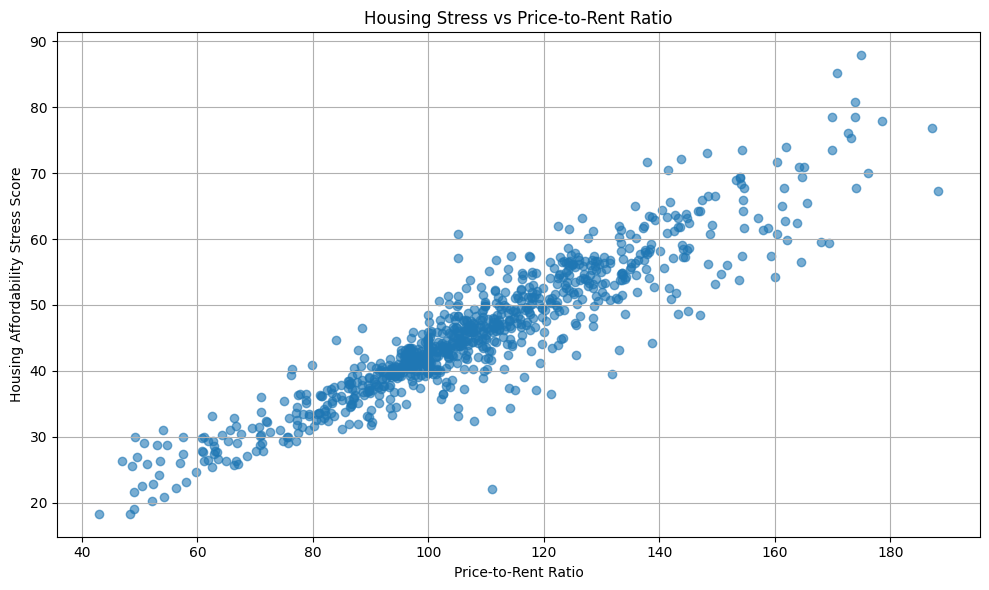

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["price_to_rent_ratio"],
    df["housing_affordability_stress_score"],
    alpha=0.6
)

plt.title("Housing Stress vs Price-to-Rent Ratio")
plt.xlabel("Price-to-Rent Ratio")
plt.ylabel("Housing Affordability Stress Score")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "stress_vs_price_to_rent.png", dpi=300)

plt.show()

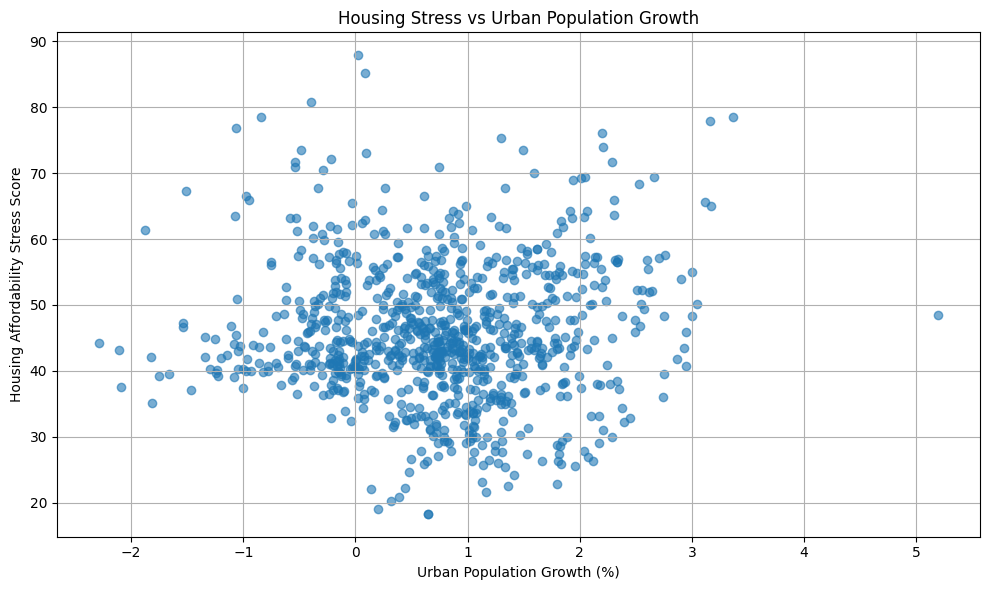

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["urban_population_growth_pct"],
    df["housing_affordability_stress_score"],
    alpha=0.6
)

plt.title("Housing Stress vs Urban Population Growth")
plt.xlabel("Urban Population Growth (%)")
plt.ylabel("Housing Affordability Stress Score")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "stress_vs_urban_population_growth.png", dpi=300)

plt.show()

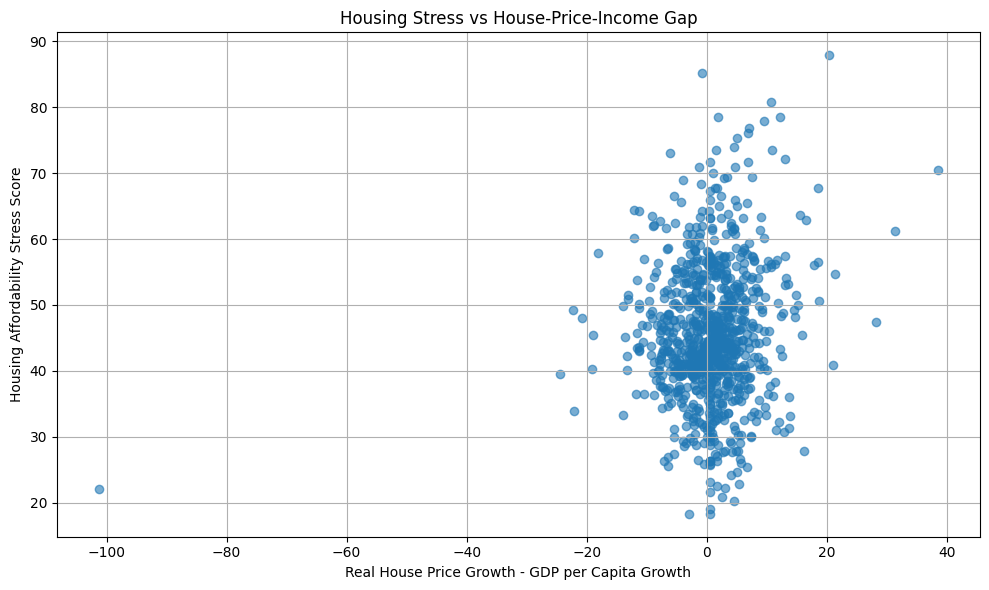

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["house_price_income_gap"],
    df["housing_affordability_stress_score"],
    alpha=0.6
)

plt.title("Housing Stress vs House-Price-Income Gap")
plt.xlabel("Real House Price Growth - GDP per Capita Growth")
plt.ylabel("Housing Affordability Stress Score")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "stress_vs_house_price_income_gap.png", dpi=300)

plt.show()

In [17]:
driver_columns = [
    "housing_affordability_stress_score",
    "price_to_income_ratio",
    "price_to_rent_ratio",
    "real_house_price_index",
    "urban_population_growth_pct",
    "house_price_income_gap",
    "gdp_per_capita_constant_usd",
    "inflation_pct",
    "unemployment_pct"
]

correlation_table = (
    df[driver_columns]
    .corr(numeric_only=True)["housing_affordability_stress_score"]
    .sort_values(ascending=False)
)

correlation_table

housing_affordability_stress_score    1.000000
real_house_price_index                0.929303
price_to_rent_ratio                   0.922662
price_to_income_ratio                 0.906401
inflation_pct                         0.303048
house_price_income_gap                0.135008
urban_population_growth_pct           0.024577
gdp_per_capita_constant_usd          -0.042825
unemployment_pct                     -0.135792
Name: housing_affordability_stress_score, dtype: float64

### Initial Insight

The driver analysis compares the stress score with its key underlying indicators. Since the stress score is partially constructed from price-to-income, real house prices, price-to-rent, urban population growth, and the house-price-income gap, strong relationships with these variables are expected.

The purpose of this step is not to prove causality. It is to understand which indicators move most closely with the stress score and to prepare clear dashboard explanations for stakeholders.

### Driver Analysis Interpretation

The strongest correlations with the Housing Affordability Stress Score are real house prices, price-to-rent ratios, and price-to-income ratios. This is expected because these variables are major components of the custom stress score.

The result suggests that, within this dataset, affordability stress is primarily associated with housing market valuation pressure rather than urban population growth alone.

Urban population growth has a much weaker correlation with the stress score. This does not mean urbanization is irrelevant. Instead, it suggests that country-level urban population growth may not fully capture local housing supply constraints, city-level demand pressure, zoning restrictions, or mortgage market conditions.

This finding is important for the dashboard story: affordability stress should be explained as a combination of price pressure, income pressure, rent pressure, and demographic context rather than as a single-factor problem.

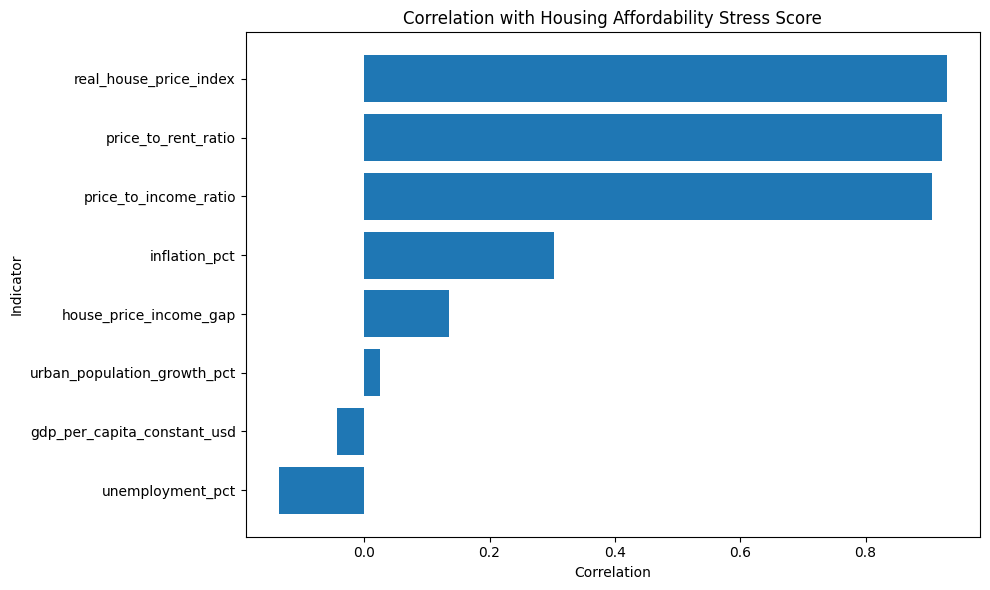

In [18]:
correlation_plot = correlation_table.drop("housing_affordability_stress_score").sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    correlation_plot.index,
    correlation_plot.values
)

plt.title("Correlation with Housing Affordability Stress Score")
plt.xlabel("Correlation")
plt.ylabel("Indicator")
plt.tight_layout()

plt.savefig(IMAGES_DIR / "correlation_with_housing_stress_score.png", dpi=300)

plt.show()